# ML & DL Exam


**Import and Util functions**

In [1]:
#------------------------------
# Global Variables
#------------------------------
SEED = 42

#------------------------------
# Global import
#------------------------------
import pandas as pd
from matplotlib import pyplot as plt 
import seaborn as sns
import numpy as np


In [13]:
def plot_heatmap(
    data_i: np.ndarray,
    title_i: str = 'Heatmap',
    color_i: str = 'coolwarm',
    format_i: str = '.2f'
) -> None:
    """
    Plot an Heat-map of the matrix given as data_i input.

    Parameters
    ----------
    data_i : array_like
        data matrix to plot
    title_i : str
        title of the plot. Default is 'Heatmap'
    color_i : str
        color map to use. Default is 'coolwarm'
    format_i : str
        format of the values to plot. Default is '.2f'

    Return
    -------
    None
    """
    

    fig = plt.figure(figsize=[5.4, 3.8], dpi=300)
    ax = fig.add_axes([0,0,1,1])
    sns.heatmap(data_i, annot=True, cmap=color_i, fmt=format_i)
    plt.title(title_i)
    plt.tight_layout()
    plt.show()

########################################

def plot_scatter(
  data_i: np.ndarray,
  classes_i: np.ndarray = None,
  labels_i: list[str] = None,
  marker_i: str = None,
  title_i: str = 'Scatter plot',
  xlabel_i: str = 'xlabel',
  ylabel_i: str = 'ylabel'
) -> None:
    """
    Plot the Scatter plot of the data_i.

    Parameters
    ----------
    data_i : array_like
        data matrix to plot. Data are arranged by rows,
        columns are the axis (x, y)
    classes_i: array_like, default=None
        list of classes to plot. Default is None.
        If classes is not None, labels shall be provided.
    labels_i : list[str]        labels of the plot. Default is None.
        If Labels is not None, a mask is appled to the rows of
        the data_i and only the rows of data_i and a scatter is plotted
        for each lablel (i.e. a class).
    marker_i : str
        marker to use. Default is None

    title_i : str
        title of the plot. Default is 'Scatter plot'
    xlabel_i : str
        label of the x-axis. Default is 'xlabel'
    ylabel_i : str
        label of the y-axis. Default is 'ylabel'
    Return
    ------
    None
    """

    plt.figure(figsize=[6, 4.5], dpi=300)
    plt.xlabel(xlabel_i)
    plt.ylabel(ylabel_i)
    plt.title(title_i)

    if(labels_i != None):

        for idx, l in enumerate(labels_i):
            plt.scatter(x=data_i[ idx == classes_i, 0], y=data_i[ idx == classes_i, 1], 
                marker=marker_i, label=l, alpha=0.6)
        plt.legend()

    else:
        plt.scatter(x=data_i[:, 0], y=data_i[:, 1], marker=marker_i)

    plt.tight_layout()
    plt.show()

########################################

def compute_correlation(df, abs_val=True, tri_sup=True):

  corr_matrix = ( X_var.corr()).to_numpy()
  if(abs_val):
    corr_matrix = np.abs(corr_matrix)
  
  if(tri_sup):
    corr_sup = np.zeros(corr_matrix.shape)
    for i in range(0, corr_sup.shape[0]):
      for j in range(0, corr_sup.shape[0]):
        if j > i:
          corr_sup[i, j] = corr_matrix[i, j]
    corr_matrix = corr_sup

  return corr_matrix

## 1. Data Preparation

In [ ]:
#------------------------------
# Loading
#------------------------------

DATASET_PATH = "./Dataset/train_dataset.csv"

# Load training set in a Pandas Dataframe
df = pd.read_csv(DATASET_PATH)

# Store target number and label
targets = df['target'].to_numpy(dtype=int)
targets_names = list( df['target_name'].unique() )

print('Dataset shape: ', df.shape)
df.head()

[4 4 4 ... 1 1 1]
[7 7 7 ... 7 7 7]
[False False False ... False False False]
Dataset shape:  (7352, 564)


,subject_id,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",target_name,target
0,1,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING,4
1,1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING,4
2,1,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING,4
3,1,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING,4
4,1,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING,4


### 1.1. Statistics

In [ ]:
# Main statistics
df.describe()


**Study the variance**

In [4]:
#------------------------------
# Import
#------------------------------
from sklearn.feature_selection import VarianceThreshold

# Remove subject id, target name (which is string so gives problems) ans target
X = df.drop(labels=['subject_id', 'target_name', 'target'], axis=1)
# Compute features variance
variance = X.var()
variance.sort_values(ascending=False)

#------------------------------
# Variance analysic
#------------------------------
vt = VarianceThreshold(threshold=0.1) # 0.1 arbitrary
X_var = vt.fit_transform(X)
print('New X shape: ', X_var.shape)

# Reput X_var in a dataframe
X_var = pd.DataFrame(data=X_var, columns=X.columns[ vt.get_support() ] )
X_var.head()

New X shape:  (7352, 189)


,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-sma(),...,fBodyBodyGyroMag-entropy(),fBodyBodyGyroMag-skewness(),fBodyBodyGyroMag-kurtosis(),fBodyBodyGyroJerkMag-entropy(),fBodyBodyGyroJerkMag-skewness(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)"
0,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,0.852947,0.685845,-0.965523,...,-0.701291,0.586156,0.374605,-0.871306,-0.298676,-0.112754,0.030400,-0.464761,-0.018446,-0.841247
1,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,0.849308,0.685845,-0.981930,...,-0.720683,-0.336310,-0.720015,-1.000000,-0.595051,0.053477,-0.007435,-0.732626,0.703511,-0.844788
2,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,0.843609,0.682401,-0.983478,...,-0.736521,-0.535352,-0.871914,-1.000000,-0.390748,-0.118559,0.177899,0.100699,0.808529,-0.848933
3,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,0.843609,0.682401,-0.986093,...,-0.720891,-0.230091,-0.511217,-0.955696,-0.117290,-0.036788,-0.012892,0.640011,-0.485366,-0.848649
4,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,0.849095,0.683250,-0.992653,...,-0.763372,-0.510282,-0.830702,-1.000000,-0.351471,0.123320,0.122542,0.693578,-0.615971,-0.847865


**Correlazione**

In [ ]:
#------------------------------
# Correlation analysis
#------------------------------
corr_matrix = compute_correlation(X_var)
plot_heatmap(corr_matrix)

### 1.2 Data visualization and patterns search

**Use t-SNE to visualize the data in 2D**

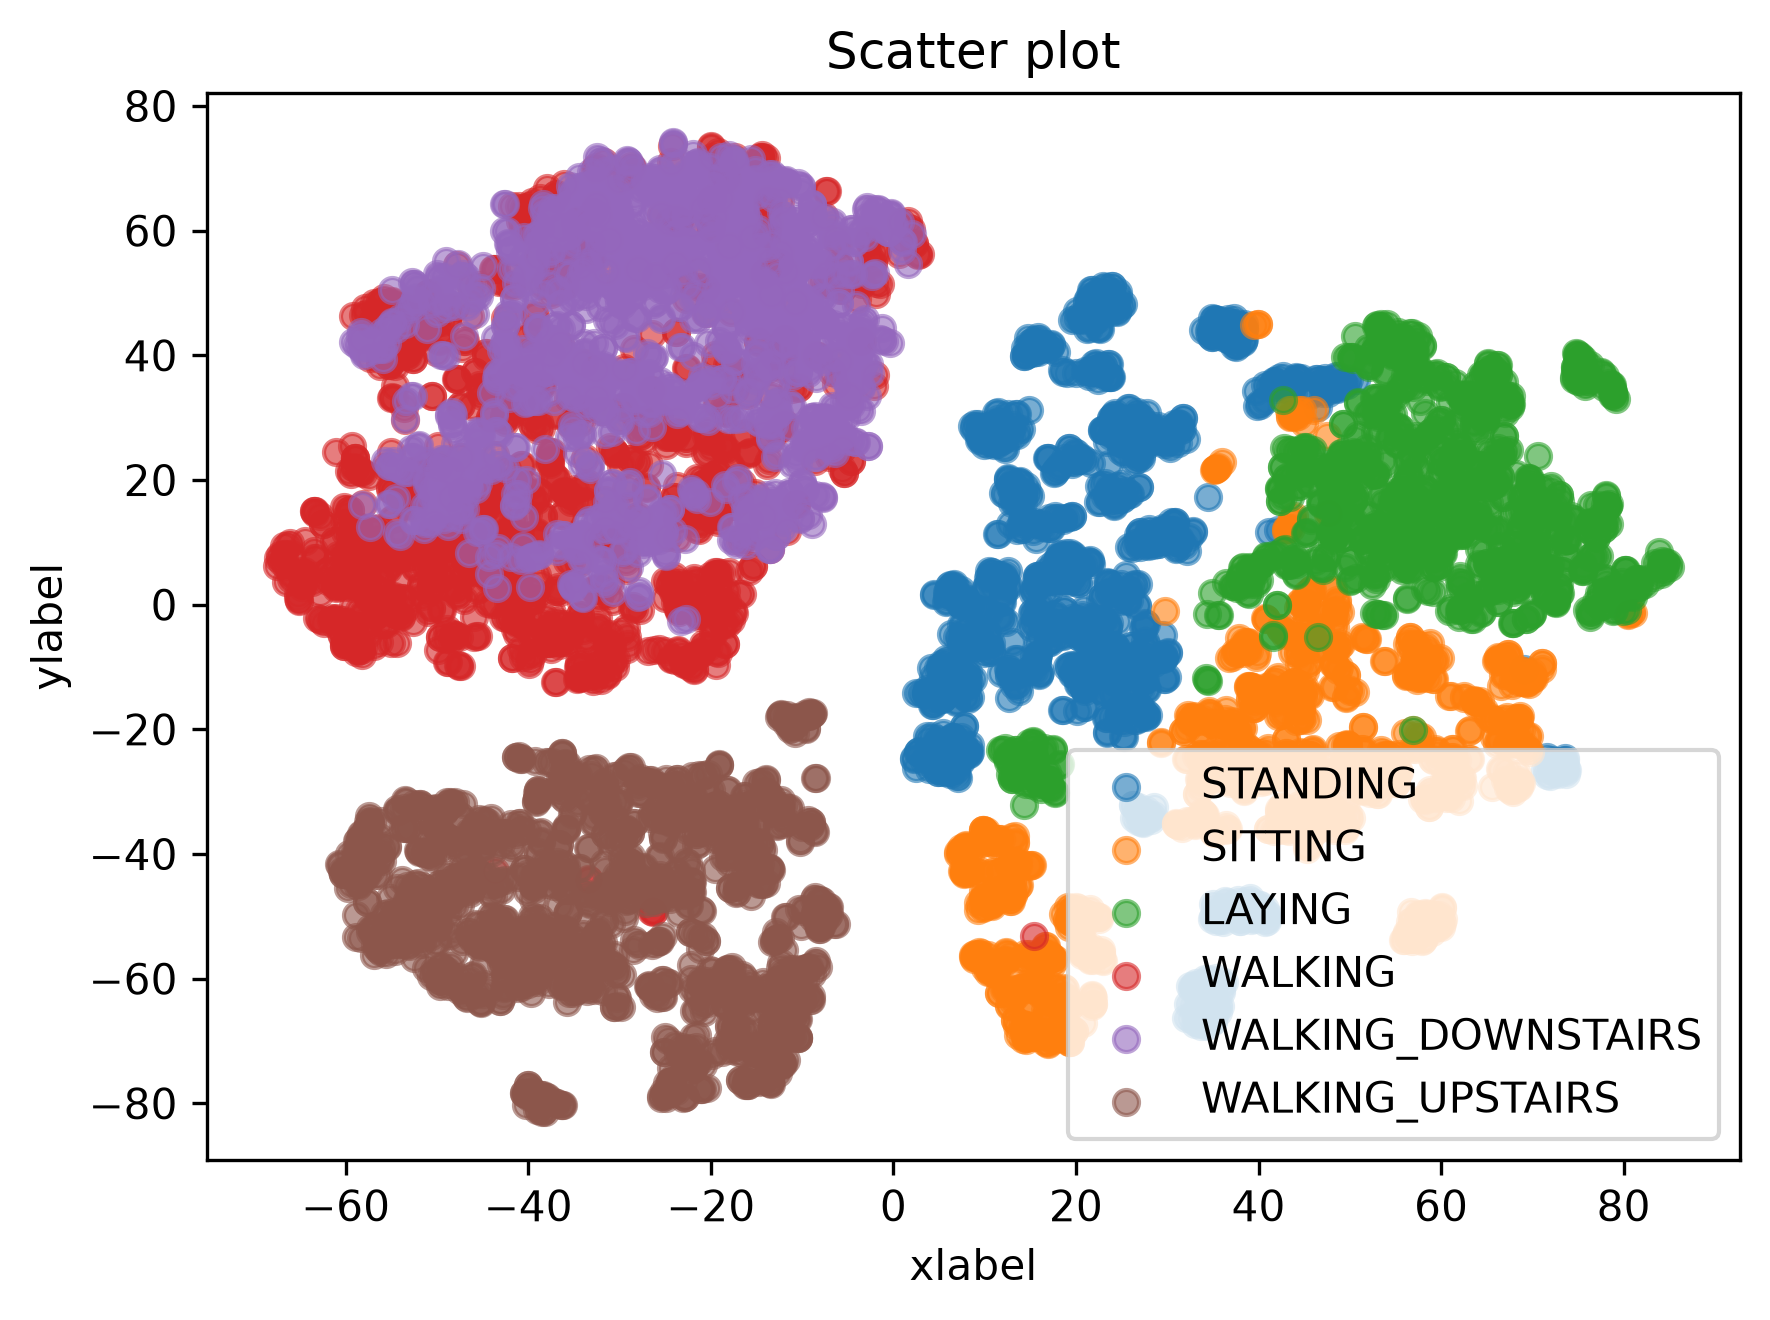

In [14]:
#------------------------------
# Import
#------------------------------
from sklearn.manifold import TSNE

#------------------------------
# Analysis
#------------------------------

# t-SNE projection in 2D
t_sne = TSNE(n_components=2, random_state=SEED, perplexity=30, learning_rate=200)
X_2d = t_sne.fit_transform(X_var)

plot_scatter(X_2d, classes_i=targets, labels_i=targets_names)